In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score , mean_squared_error 

In [2]:
data = pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
data.describe()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [4]:
X = data[["Tutoring_Sessions" , "Physical_Activity" , "Previous_Scores", "Sleep_Hours"]]
X

,Tutoring_Sessions,Physical_Activity,Previous_Scores,Sleep_Hours
0,0,3,73,7
1,2,4,59,8
2,2,4,91,7
3,1,4,98,8
4,3,4,65,6
...,...,...,...,...
6602,1,2,76,7
6603,3,2,81,8
6604,3,2,65,6
6605,2,3,91,6


In [5]:
Y = data["Exam_Score"]
Y

0       67
1       61
2       74
3       71
4       70
        ..
6602    68
6603    69
6604    68
6605    68
6606    64
Name: Exam_Score, Length: 6607, dtype: int64

In [6]:
lr = LinearRegression()

In [7]:
lr.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
print(lr.coef_[:])
print(lr.intercept_)

[ 0.50025949  0.10190677  0.04787923 -0.02974285]
62.80073753442252


In [9]:
Y_pred = lr.predict(X)
Y_pred

array([66.39344178, 66.79581545, 68.3576937 , ..., 67.43902249,
       68.28552978, 67.44132671], shape=(6607,))

In [10]:
r2 = r2_score(Y,Y_pred)
print(r2)
mse = mean_squared_error(Y,Y_pred)
print(mse)

0.05673713594445384
14.274732096927464


In [11]:
residuals = Y - Y_pred
data["Residuals"] = residuals
data


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Residuals
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Medium,Public,Positive,3,No,High School,Near,Male,67,0.606558
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Medium,Public,Negative,4,No,College,Moderate,Female,61,-5.795815
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,5.642306
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Medium,Public,Negative,4,No,High School,Moderate,Male,71,2.837154
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,High,Public,Neutral,4,No,College,Near,Female,70,2.357164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Medium,Public,Positive,2,No,High School,Near,Female,68,1.064568
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,High,Public,Positive,2,No,High School,Near,Female,69,0.854396
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68,0.560978
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Medium,Private,Positive,3,No,High School,Far,Female,68,-0.285530


In [12]:
residuals_sq = residuals ** 2
data["Residuals^2"] = residuals_sq
data

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Residuals,Residuals^2
0,23,84,Low,High,No,7,73,Low,Yes,0,...,Public,Positive,3,No,High School,Near,Male,67,0.606558,0.367913
1,19,64,Low,Medium,No,8,59,Low,Yes,2,...,Public,Negative,4,No,College,Moderate,Female,61,-5.795815,33.591477
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,...,Public,Neutral,4,No,Postgraduate,Near,Male,74,5.642306,31.835620
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,...,Public,Negative,4,No,High School,Moderate,Male,71,2.837154,8.049443
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,...,Public,Neutral,4,No,College,Near,Female,70,2.357164,5.556222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,...,Public,Positive,2,No,High School,Near,Female,68,1.064568,1.133305
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,...,Public,Positive,2,No,High School,Near,Female,69,0.854396,0.729992
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,...,Public,Negative,2,No,Postgraduate,Near,Female,68,0.560978,0.314696
6605,10,86,High,High,Yes,6,91,High,Yes,2,...,Private,Positive,3,No,High School,Far,Female,68,-0.285530,0.081527


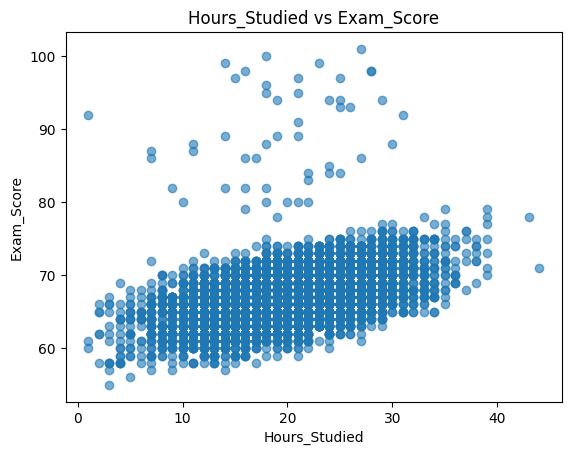

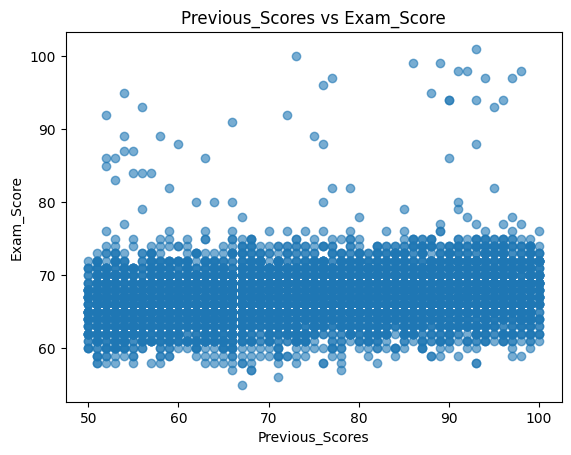

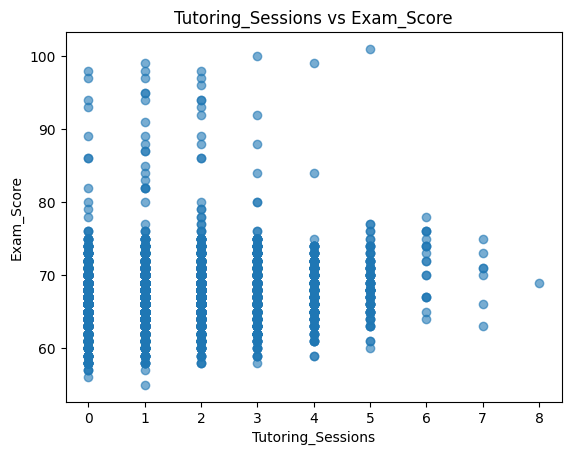

In [16]:
pairs = [
    ('Hours_Studied', 'Exam_Score'),
    ('Previous_Scores', 'Exam_Score'),
    ('Tutoring_Sessions', 'Exam_Score')
]

for X, Y in pairs:
    plt.figure()
    plt.scatter(data[X], data[Y], alpha=0.6) 
    plt.title(f'{X} vs {Y}')
    plt.xlabel(X)
    plt.ylabel(Y)
    plt.show()